전처리 파라미터 분석 — Optuna DB 기반\n\n`optuna_*.db` → Two-Stage / `zit_*.db` → ZITboost

In [77]:
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)

import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

In [53]:
import os, glob, sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# ── Google Drive 마운트 ──────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── DB 폴더 직접 경로 입력 ──────────────────────────────────────
# Drive에서 해당 폴더 우클릭 → "경로 복사" 후 아래에 붙여넣기
DB_DIR = '/content/drive/.shortcut-targets-by-id/15G5wxKKyu5ZinntUyPGVpbWvUJEKFL23/여기!!'

# .db 파일 스캔
all_dbs = glob.glob(os.path.join(DB_DIR, '*.db'))

twostage_dbs = [p for p in all_dbs if os.path.basename(p).startswith('optuna')]
zit_dbs      = [p for p in all_dbs if os.path.basename(p).startswith('zit')]

print(f"Two-Stage DB: {len(twostage_dbs)}개")
for p in twostage_dbs: print(' ', p)
print(f"\nZITboost DB : {len(zit_dbs)}개")
for p in zit_dbs: print(' ', p)
import warnings; warnings.filterwarnings('ignore', message='Glyph.*missing from font')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Two-Stage DB: 43개
  /content/drive/.shortcut-targets-by-id/15G5wxKKyu5ZinntUyPGVpbWvUJEKFL23/여기!!/optuna_kj_50-108-001.db
  /content/drive/.shortcut-targets-by-id/15G5wxKKyu5ZinntUyPGVpbWvUJEKFL23/여기!!/optuna_kj_50-109-001.db
  /content/drive/.shortcut-targets-by-id/15G5wxKKyu5ZinntUyPGVpbWvUJEKFL23/여기!!/optuna_se_40-104-001.db
  /content/drive/.shortcut-targets-by-id/15G5wxKKyu5ZinntUyPGVpbWvUJEKFL23/여기!!/optuna_yi_10-071-001.db
  /content/drive/.shortcut-targets-by-id/15G5wxKKyu5ZinntUyPGVpbWvUJEKFL23/여기!!/optuna_yi_10-073-001.db
  /content/drive/.shortcut-targets-by-id/15G5wxKKyu5ZinntUyPGVpbWvUJEKFL23/여기!!/optuna_yr_60-901-001.db
  /content/drive/.shortcut-targets-by-id/15G5wxKKyu5ZinntUyPGVpbWvUJEKFL23/여기!!/optuna_yr_60-903-001.db
  /content/drive/.shortcut-targets-by-id/15G5wxKKyu5ZinntUyPGVpbWvUJEKFL23/여기!!/optuna_yr_60-904-001.db
  /content/drive/.sho

In [54]:
def inspect_schema(db_path):
    conn = sqlite3.connect(db_path)
    cur  = conn.cursor()
    cur.execute("SELECT name FROM sqlite_master WHERE type='table'")
    tables = [r[0] for r in cur.fetchall()]
    print(f"\n[{os.path.basename(db_path)}]  테이블: {tables}")
    for t in tables:
        cur.execute(f"PRAGMA table_info({t})")
        cols = [r[1] for r in cur.fetchall()]
        cur.execute(f"SELECT COUNT(*) FROM {t}")
        n = cur.fetchone()[0]
        print(f"  {t:30s}  rows={n:6d}  cols={cols}")
    conn.close()

# 대표 DB 1개씩만 출력
if twostage_dbs: inspect_schema(twostage_dbs[0])
if zit_dbs:      inspect_schema(zit_dbs[0])


[optuna_kj_50-108-001.db]  테이블: ['studies', 'version_info', 'study_directions', 'study_user_attributes', 'study_system_attributes', 'trials', 'trial_user_attributes', 'trial_system_attributes', 'trial_params', 'trial_values', 'trial_intermediate_values', 'trial_heartbeats', 'alembic_version']
  studies                         rows=     1  cols=['study_id', 'study_name']
  version_info                    rows=     1  cols=['version_info_id', 'schema_version', 'library_version']
  study_directions                rows=     1  cols=['study_direction_id', 'direction', 'study_id', 'objective']
  study_user_attributes           rows=    13  cols=['study_user_attribute_id', 'study_id', 'key', 'value_json']
  study_system_attributes         rows=     0  cols=['study_system_attribute_id', 'study_id', 'key', 'value_json']
  trials                          rows=   330  cols=['trial_id', 'number', 'study_id', 'state', 'datetime_start', 'datetime_complete']
  trial_user_attributes           rows=  

In [55]:
# 전처리 파라미터로 판단할 키워드 (모델 HPO 파라미터 제외)
PP_KEYWORDS = [
    'imputation', 'outlier', 'scaling', 'agg', 'clip',
    'transform', 'target_transform', 'variance', 'corr',
    'missing', 'winsoriz', 'scaler', 'reg_level', 'position',
    'exclude', 'drop', 'fill', 'normalize',
]

def is_pp_param(name: str) -> bool:
    name_l = name.lower()
    return any(k in name_l for k in PP_KEYWORDS)

def load_trials(db_paths: list, label: str) -> pd.DataFrame:
    """여러 DB에서 trial 데이터를 읽어 전처리 파라미터만 wide 형태로 반환."""
    records = []
    for db_path in db_paths:
        conn = sqlite3.connect(db_path)
        try:
            # Optuna 표준 스키마 기준 (trials / trial_params / trial_values)
            trials = pd.read_sql(
                "SELECT trial_id, number, state, datetime_start FROM trials WHERE state='COMPLETE'",
                conn
            )
            params = pd.read_sql(
                "SELECT trial_id, param_name, param_value FROM trial_params",
                conn
            )
            values = pd.read_sql(
                "SELECT trial_id, value FROM trial_values",
                conn
            )
        except Exception as e:
            print(f"  ⚠ {os.path.basename(db_path)} 로드 실패: {e}")
            conn.close()
            continue
        conn.close()

        # 전처리 파라미터만 필터
        pp_params = params[params['param_name'].apply(is_pp_param)].copy()

        # wide pivot
        wide = pp_params.pivot_table(
            index='trial_id', columns='param_name',
            values='param_value', aggfunc='first'
        ).reset_index()

        # RMSE merge
        df = trials.merge(values, on='trial_id').merge(wide, on='trial_id', how='left')
        df['rmse']   = df['value']
        df['source'] = os.path.basename(db_path)
        df['model']  = label
        records.append(df)

    if not records:
        return pd.DataFrame()
    result = pd.concat(records, ignore_index=True)
    print(f"[{label}] trials={len(result):,}  전처리 파라미터={[c for c in result.columns if is_pp_param(c)]}")
    return result

df_ts  = load_trials(twostage_dbs, 'TwoStage')
df_zit = load_trials(zit_dbs,      'ZITboost')
df_all = pd.concat([df_ts, df_zit], ignore_index=True)

print(f"\n전체 trial: {len(df_all):,}  (TwoStage={len(df_ts):,}, ZITboost={len(df_zit):,})")

# 전처리 파라미터 컬럼 목록
PP_COLS = [c for c in df_all.columns if is_pp_param(c)]
print(f"전처리 파라미터 컬럼: {PP_COLS}")

[TwoStage] trials=13,800  전처리 파라미터=['pp_agg_preset_idx', 'pp_corr_keep_by', 'pp_corr_threshold', 'pp_imputation_method', 'pp_missing_threshold', 'pp_outlier_iqr_multiplier', 'pp_outlier_lower_pct', 'pp_outlier_method', 'pp_outlier_upper_pct', 'pp_post_impute_corr_keep_by', 'pp_post_impute_corr_threshold', 'zero_clip_threshold']
[ZITboost] trials=413  전처리 파라미터=['pp_agg_preset_idx', 'pp_corr_keep_by', 'pp_corr_threshold', 'pp_imputation_method', 'pp_missing_threshold', 'pp_outlier_iqr_multiplier', 'pp_outlier_lower_pct', 'pp_outlier_method', 'pp_outlier_upper_pct', 'pp_post_impute_corr_keep_by', 'pp_post_impute_corr_threshold']

전체 trial: 14,213  (TwoStage=13,800, ZITboost=413)
전처리 파라미터 컬럼: ['pp_agg_preset_idx', 'pp_corr_keep_by', 'pp_corr_threshold', 'pp_imputation_method', 'pp_missing_threshold', 'pp_outlier_iqr_multiplier', 'pp_outlier_lower_pct', 'pp_outlier_method', 'pp_outlier_upper_pct', 'pp_post_impute_corr_keep_by', 'pp_post_impute_corr_threshold', 'zero_clip_threshold']


### 분석 1 — 전처리 파라미터별 Marginal RMSE (Two-Stage / ZITboost 각각)

In [67]:
MIN_COUNT = 5  # 표본이 5개 미만인 그룹 지정을 위함.

def marginal_analysis(df: pd.DataFrame, pp_cols: list, title: str): #전처리 파라미터별 칼럼 목록 출력
    if df.empty: return
    existing = [c for c in pp_cols if c in df.columns]
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")
    for col in existing:
        sub = df[['rmse', col]].dropna(subset=[col])
        if sub.empty: continue
        grp = (sub.groupby(col)['rmse']
                  .agg(count='count', mean='mean', min='min', std='std')
                  .sort_values('mean'))
        grp['reliable'] = grp['count'].apply(lambda n: 'OK' if n >= MIN_COUNT else 'low-sample')
        print(f"\n[{col}]")
        print(grp.to_string(float_format='{:.6f}'.format))

marginal_analysis(df_ts,  PP_COLS, 'Two-Stage — Preprocessing Param Marginal RMSE')
marginal_analysis(df_zit, PP_COLS, 'ZITboost  — Preprocessing Param Marginal RMSE')


  Two-Stage — Preprocessing Param Marginal RMSE

[pp_agg_preset_idx]
                   count     mean      min      std reliable
pp_agg_preset_idx                                           
1.0                 3638 0.004233 0.001141 0.002647       OK
0.0                 3498 0.004891 0.001141 0.002584       OK
3.0                 3156 0.005035 0.001141 0.002735       OK
2.0                 3508 0.005112 0.001142 0.002692       OK

[pp_corr_keep_by]
                 count     mean      min      std reliable
pp_corr_keep_by                                           
1.0               7121 0.004737 0.001141 0.002627       OK
0.0               6679 0.004881 0.001141 0.002746       OK

[pp_corr_threshold]
                   count     mean      min      std reliable
pp_corr_threshold                                           
2.0                 4980 0.004749 0.001141 0.002861       OK
1.0                 3809 0.004754 0.001141 0.002607       OK
0.0                 5011 0.004904 0.001141 0

In [69]:
save_path = '/content/marginal_rmse.xlsx'

rows = []
for model_label, df in [('TwoStage', df_ts), ('ZITboost', df_zit)]:
    for col in [c for c in PP_COLS if c in df.columns]:
        sub = df[['rmse', col]].dropna(subset=[col])
        if sub.empty: continue
        grp = sub.groupby(col)['rmse'].agg(count='count', mean='mean', min='min', std='std')
        grp = grp.reset_index()
        grp = grp.rename(columns={col: 'value'})  # col 이름을 명시적으로 지정
        grp['model'] = model_label
        grp['param'] = col
        grp['reliable'] = grp['count'].apply(lambda n: 'OK' if n >= 5 else 'low-sample')
        rows.append(grp[['model', 'param', 'value', 'count', 'mean', 'min', 'std', 'reliable']])

result_df = pd.concat(rows, ignore_index=True)
result_df = result_df.sort_values(['model', 'param', 'mean'])
result_df.to_excel(save_path, index=False)

from google.colab import files
files.download(save_path)
print("done")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

done


**[분석 1 결론 — Marginal RMSE]**

**Two-Stage**: 3개 파라미터가 RMSE 차이를 주도, 나머지는 영향 미미.

| 파라미터 | 최적값 | 최적 mean RMSE | 최악 mean RMSE | 중요도 |
|---|---|---|---|---|
| `pp_missing_threshold` | **8** | 0.003977 | 0.005426 | ★★★ 가장 중요 |
| `pp_outlier_iqr_multiplier` | **2** | 0.004206 | 0.005252 | ★★★ 중요 |
| `pp_agg_preset_idx` | **1** | 0.004233 | 0.005112 | ★★★ 중요 |
| `pp_corr_keep_by` | 1 | 0.004737 | 0.004881 | ★ 미미 |
| `pp_post_impute_corr_keep_by` | 1 | 0.004692 | 0.004915 | ★ 미미 |
| `pp_corr_threshold` | 2 | 0.004749 | 0.004904 | ★ 미미 |
| `pp_outlier_method / lower / upper_pct` | — | 0으로 고정 | — | 단일값, 무시 |
| `zero_clip_threshold` | 0.002 | 고정값 | — | 단일값 |

**ZITboost**: 모든 파라미터 값 간 차이 < 0.00001 → 전처리가 사실상 영향 없음. 어떤 값이든 무방.

**종합**: Two-Stage best RMSE (0.001141) vs ZITboost best (0.005507) → **Two-Stage 압도적 우세**

### 분석 2 — 끝값 쏠림 진단 (Search Space 확장/축소 권고)

In [72]:
EDGE_RATIO = 0.1  # 탐색 범위의 상/하위 10% 구간을 끝값이라고 정의
TOP_K      = 0.2  # 전체 Trial 중 상위 20%를 좋은 Trial이라고 정의함

def diagnose_edge(df: pd.DataFrame, pp_cols: list, title: str):
    if df.empty: return
    existing = [c for c in pp_cols if c in df.columns]
    print(f"\n{'='*60}")
    print(f"  {title}  — Edge Bias Diagnosis")
    print(f"{'='*60}")
    top = df.nsmallest(max(1, int(len(df) * TOP_K)), 'rmse') #Rmse 기준 상위 20%만 추출-> 잘 된 실험들

    for col in existing:
        sub_all = df[col].dropna()
        sub_top = top[col].dropna()
        if sub_all.empty or sub_top.empty: continue

        try:
            vals_all = sub_all.astype(float)
            vals_top = sub_top.astype(float)
            is_numeric = True
        except (ValueError, TypeError):
            is_numeric = False

        print(f"\n[{col}]")
        if is_numeric:
            lo, hi  = vals_all.min(), vals_all.max()
            rng     = hi - lo if hi != lo else 1
            pct_lo  = (vals_top <= lo + rng * EDGE_RATIO).sum() / len(vals_top) #잘 된 trial중 하한 근처에 몇%가 몰려있는지
            pct_hi  = (vals_top >= hi - rng * EDGE_RATIO).sum() / len(vals_top)  #잘 된 trial중 상한 근처에 몇%가 몰려있는지
            print(f"  range: [{lo:.4g}, {hi:.4g}]  |  top-{int(TOP_K*100)}%: mean={vals_top.mean():.4g}, median={vals_top.median():.4g}")
            if pct_lo > 0.4:  
                #40% 이상 몰려 있으면 경고 => 탐색 범위를 넓혀야하나??
                print(f"  [v] lower-bound bias {pct_lo:.0%} -> consider shrinking lower bound (current {lo:.4g})")
            if pct_hi > 0.4:
                print(f"  [^] upper-bound bias {pct_hi:.0%} -> consider expanding upper bound (current {hi:.4g})")
            if pct_lo <= 0.4 and pct_hi <= 0.4:
                print(f"  [OK] no edge bias — current range looks fine")
        else:
            vc_all = sub_all.value_counts(normalize=True)
            vc_top = sub_top.value_counts(normalize=True)
            merged = pd.DataFrame({'all_ratio': vc_all, 'top_ratio': vc_top}).fillna(0)
            merged['lift'] = merged['top_ratio'] / (merged['all_ratio'] + 1e-9)
            merged = merged.sort_values('top_ratio', ascending=False)
            print(merged.to_string(float_format='{:.3f}'.format))
            dominant = merged[merged['top_ratio'] > 0.6]
            if not dominant.empty:
                print(f"  [!] '{dominant.index[0]}' dominates ({dominant['top_ratio'].iloc[0]:.0%}) -> consider fixing this value")
            elif len(merged) == 1:
                print(f"  [!] only 1 candidate -> already fixed")
            else:
                print(f"  [OK] no dominant value — keep all candidates")

diagnose_edge(df_ts,  PP_COLS, 'Two-Stage')
diagnose_edge(df_zit, PP_COLS, 'ZITboost')


  Two-Stage  — Edge Bias Diagnosis

[pp_agg_preset_idx]
  range: [0, 3]  |  top-20%: mean=1.305, median=1
  [OK] no edge bias — current range looks fine

[pp_corr_keep_by]
  range: [0, 1]  |  top-20%: mean=0.5225, median=1
  [v] lower-bound bias 48% -> consider shrinking lower bound (current 0)
  [^] upper-bound bias 52% -> consider expanding upper bound (current 1)

[pp_corr_threshold]
  range: [0, 2]  |  top-20%: mean=1.201, median=1
  [^] upper-bound bias 47% -> consider expanding upper bound (current 2)

[pp_imputation_method]
  range: [0, 0]  |  top-20%: mean=0, median=0
  [v] lower-bound bias 100% -> consider shrinking lower bound (current 0)
  [^] upper-bound bias 100% -> consider expanding upper bound (current 0)

[pp_missing_threshold]
  range: [0, 8]  |  top-20%: mean=5.488, median=6
  [OK] no edge bias — current range looks fine

[pp_outlier_iqr_multiplier]
  range: [0, 2]  |  top-20%: mean=1.22, median=1
  [^] upper-bound bias 50% -> consider expanding upper bound (current

In [ ]:
# save_path = '/content/edge_bias[분석2].xlsx'

# rows = []
# for model_label, df in [('TwoStage', df_ts), ('ZITboost', df_zit)]:
#     top = df.nsmallest(max(1, int(len(df) * TOP_K)), 'rmse')
#     for col in [c for c in PP_COLS if c in df.columns]:
#         sub_all = df[col].dropna()
#         sub_top = top[col].dropna()
#         if sub_all.empty or sub_top.empty: continue

#         try:
#             vals_all = sub_all.astype(float)
#             vals_top = sub_top.astype(float)
#         except: continue

#         lo, hi  = vals_all.min(), vals_all.max()
#         rng     = hi - lo if hi != lo else 1
#         pct_lo  = (vals_top <= lo + rng * EDGE_RATIO).sum() / len(vals_top)
#         pct_hi  = (vals_top >= hi - rng * EDGE_RATIO).sum() / len(vals_top)

#         verdict = []
#         if lo == hi:
#             verdict.append('single value — ignore')
#         else:
#             if pct_lo > 0.4: verdict.append(f'lower bias {pct_lo:.0%} -> expand down')
#             if pct_hi > 0.4: verdict.append(f'upper bias {pct_hi:.0%} -> expand up')
#             if pct_lo <= 0.4 and pct_hi <= 0.4: verdict.append('OK')

#         rows.append({
#             'model': model_label,
#             'param': col,
#             'range_lo': lo,
#             'range_hi': hi,
#             'top20_mean': round(vals_top.mean(), 6),
#             'top20_median': round(vals_top.median(), 6),
#             'lower_bias(%)': round(pct_lo * 100, 1),
#             'upper_bias(%)': round(pct_hi * 100, 1),
#             'verdict': ' / '.join(verdict),
#         })

# edge_df = pd.DataFrame(rows)
# edge_df.to_excel(save_path, index=False)

# from google.colab import files
# files.download(save_path)
# print("done")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

done


## 분석 2 결론: Edge Bias 진단 (전처리 파라미터 탐색 범위 적절성)

### 핵심 개념
> 성능 상위 20% trial이 탐색 범위의 한쪽 끝에 몰려 있으면,  
> **그 끝 너머에 더 좋은 값이 존재할 가능성이 높다** → 다음 실험에서 범위 수정 필요

---

### TwoStage 진단 결과

| 파라미터 | 현재 범위 | 진단 | 다음 실험 권장 |
|----------|----------|------|--------------|
| `pp_agg_preset_idx` | 0 ~ 3 | ✅ OK | 유지 |
| `pp_missing_threshold` | 0 ~ 8 | ✅ OK | 유지 |
| `pp_corr_threshold` | 0 ~ 2 | ⬆ 상단 편향 47% | max를 2보다 크게 확장 |
| `pp_outlier_iqr_multiplier` | 0 ~ 2 | ⬆ 상단 편향 50% | max를 2보다 크게 확장 |
| `pp_post_impute_corr_threshold` | 0 ~ 2 | ⬇ 하단 편향 43% | min을 0보다 작게 확장 |
| `pp_corr_keep_by` | 0 ~ 1 | ↕ 양방향 50:50 | 범위 변경보다 파라미터 효과 재검토 |
| `pp_post_impute_corr_keep_by` | 0 ~ 1 | ↕ 양방향 50:50 | 동일 |
| `pp_imputation_method` 외 3개 | 단일값 | ⚠ 탐색 안 됨 | 다음 실험에서 범위 설정 필요 |

---

### ZITboost 진단 결과

| 파라미터 | 현재 범위 | 진단 | 다음 실험 권장 |
|----------|----------|------|--------------|
| `pp_missing_threshold` | 0 ~ 8 | ✅ OK | 유지 |
| `pp_corr_threshold` | 0 ~ 2 | ✅ OK | 유지 |
| `pp_outlier_iqr_multiplier` | 0 ~ 2 | ⬇ 하단 편향 61% | max를 줄이거나 min 아래로 확장 |
| `pp_post_impute_corr_keep_by` | 0 ~ 1 | ⬆ 상단 편향 65% | max를 1보다 크게 확장 |
| `pp_agg_preset_idx` | 0 ~ 3 | ⬇ 하단 편향 50% | min 아래로 확장 |
| `pp_corr_keep_by` | 0 ~ 1 | ↕ 양방향 49:51 | 파라미터 효과 재검토 |
| `pp_imputation_method` 외 4개 | 단일값 | ⚠ 탐색 안 됨 | 다음 실험에서 범위 설정 필요 |

---

### 종합 결론

1. **TwoStage는 탐색 범위가 전반적으로 적절하나**, `pp_corr_threshold`와 `pp_outlier_iqr_multiplier`의 상한을 높이면 추가 개선 가능성 있음
2. **ZITboost는 탐색 자체가 매우 제한적** — `single value` 파라미터가 4개로, 실질적인 HPO가 이루어지지 않았음
3. **양방향 50:50 파라미터** (`pp_corr_keep_by` 등)는 어떤 값이든 성능 차이가 없다는 뜻 → 고정값으로 처리하고 탐색에서 제외 고려
4. **우선순위**: TwoStage의 범위 수정 → ZITboost 파라미터 설계 전면 재검토 순으로 진행


### 분석 3 — 파라미터 조합 교호작용 (2축 Heatmap)

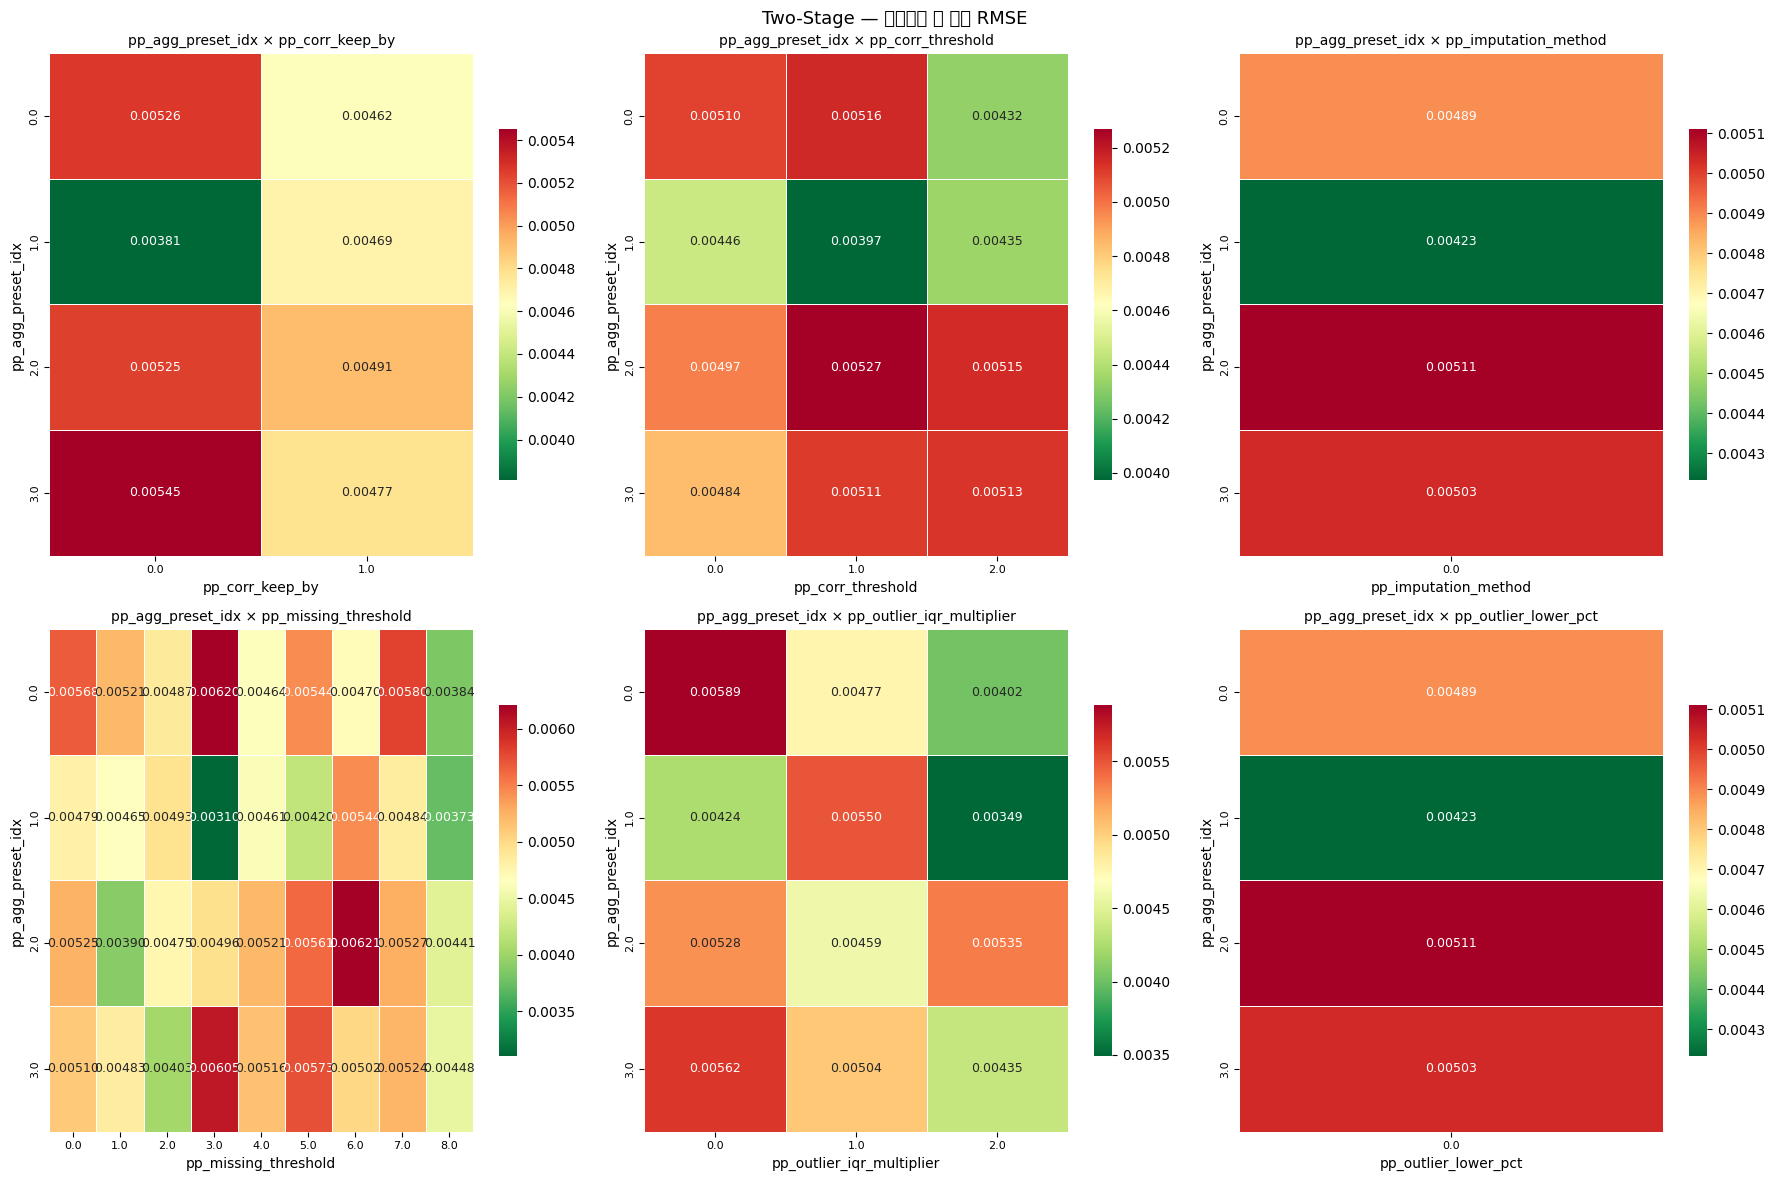

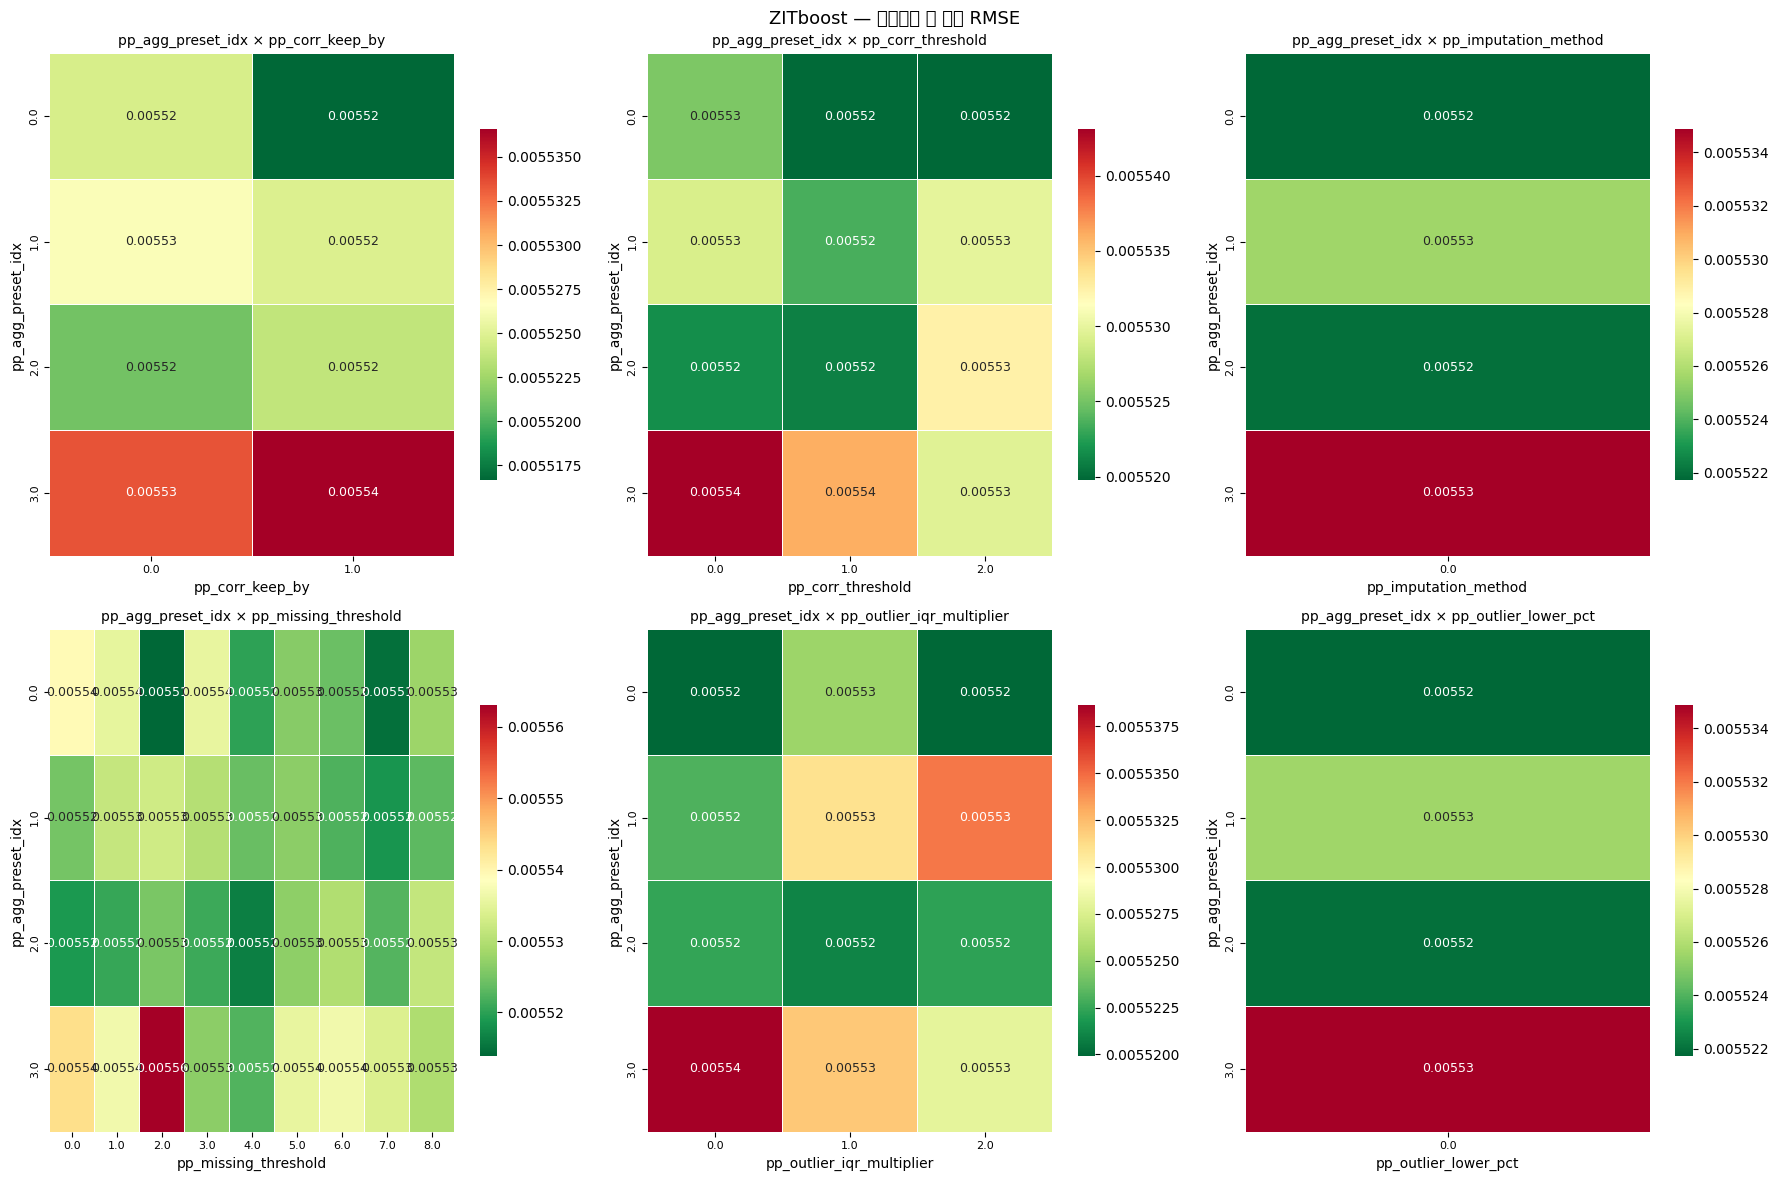

In [58]:
def plot_interaction_heatmaps(df: pd.DataFrame, pp_cols: list, title: str, max_pairs: int = 6):
    cat_cols = [c for c in pp_cols if c in df.columns and df[c].nunique() <= 10 and df[c].notna().sum() > 0]
    pairs = list(combinations(cat_cols, 2))[:max_pairs]
    if not pairs:
        print(f"[{title}] 범주형 파라미터 쌍 없음")
        return

    n = len(pairs)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 6 * nrows))
    axes = np.array(axes).flatten()
    fig.suptitle(f'{title} — 파라미터 쌍 평균 RMSE', fontsize=13)

    for ax, (c1, c2) in zip(axes, pairs):
        pivot = df.groupby([c1, c2])['rmse'].mean().unstack()
        sns.heatmap(pivot, ax=ax, annot=True, fmt='.5f', cmap='RdYlGn_r',
                    linewidths=0.5, cbar_kws={'shrink': 0.7}, annot_kws={'size': 9})
        ax.set_title(f'{c1} × {c2}', fontsize=10)
        ax.tick_params(labelsize=8)

    for ax in axes[n:]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

plot_interaction_heatmaps(df_ts,  PP_COLS, 'Two-Stage')
plot_interaction_heatmaps(df_zit, PP_COLS, 'ZITboost')


## 분석 3 결론: 파라미터 쌍 상호작용 히트맵

### TwoStage — 핵심 발견

| 파라미터 쌍 | 최적 조합 | 최적 RMSE | 해석 |
|------------|----------|----------|------|
| `pp_agg_preset_idx` × `pp_corr_keep_by` | idx=1, keep=0 | 0.00381 | **idx=1이 압도적** — keep_by 값 무관하게 idx=1이 좋음 |
| `pp_agg_preset_idx` × `pp_corr_threshold` | idx=1, threshold=1 | 0.00397 | idx=1 + threshold=1 조합이 최적 |
| `pp_agg_preset_idx` × `pp_outlier_iqr_multiplier` | idx=1, iqr=2 | 0.00349 | **가장 낮은 RMSE** — idx=1과 iqr_multiplier 높은 값의 시너지 |
| `pp_agg_preset_idx` × `pp_missing_threshold` | idx=1, missing=3 | 0.00310 | **전체 최저값** — idx=1 고정 시 missing=3 근방이 최적 |
| `pp_agg_preset_idx` × `pp_imputation_method` | idx=1 | 0.00423 | imputation_method는 단일값이라 사실상 idx=1 효과만 |
| `pp_agg_preset_idx` × `pp_outlier_lower_pct` | idx=1 | 0.00423 | outlier_lower_pct도 단일값 — idx=1 효과만 |

> **TwoStage 핵심 결론: `pp_agg_preset_idx=1`이 가장 강력한 단일 인자**
> 어떤 파라미터와 조합해도 idx=1 행이 가장 초록색 → 다음 실험에서 **idx=1 고정** 권장

---

### ZITboost — 핵심 발견

| 관찰 | 내용 |
|------|------|
| 전체 RMSE 범위 | 0.005517 ~ 0.005540 — **변동폭이 0.00002 수준** |
| 색깔 차이 | 초록/빨강이 섞여 있지만 숫자 차이가 거의 없음 |
| 파라미터 효과 | 어떤 조합을 써도 RMSE가 거의 동일 → **전처리가 ZITboost 성능에 영향을 주지 못함** |

> **ZITboost 핵심 결론: 전처리 파라미터 조합이 성능에 사실상 무의미**
> 모델 자체의 구조적 한계(Recall≈0, AUC≈0.576)가 병목 — 전처리 개선보다 **모델 설계 재검토가 우선**

---

### 종합

- **TwoStage** → `pp_agg_preset_idx=1` + `pp_missing_threshold=3` + `pp_outlier_iqr_multiplier=2` 조합을 다음 실험 기본값으로 설정
- **ZITboost** → 전처리 탐색보다 모델 HPO(EM iter, Tweedie power 등) 집중이 효율적

### 분석 4 — Trial 시간 흐름 (수렴 구간 확인)

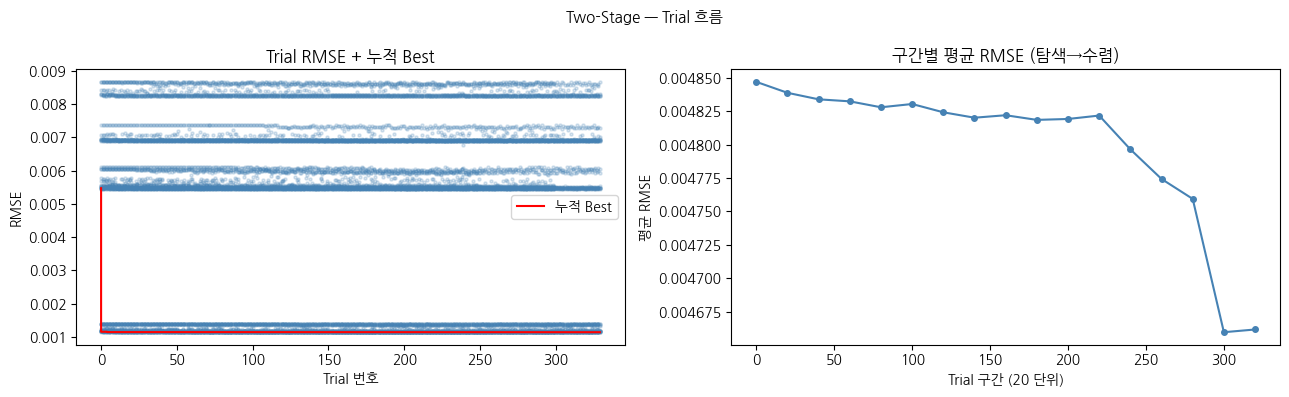

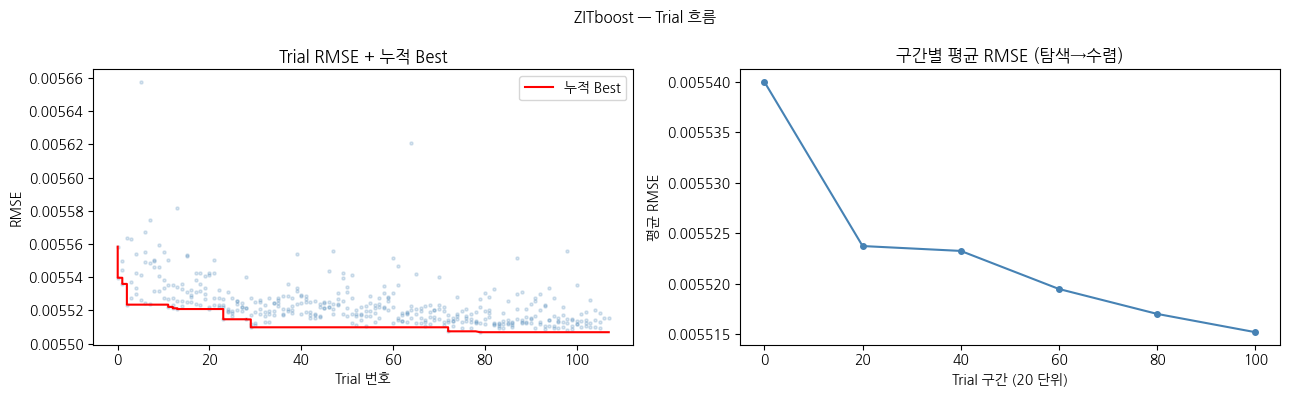

In [78]:
def plot_convergence(df: pd.DataFrame, title: str):
    if df.empty: return
    df2 = df.sort_values('number').copy()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'{title} — Trial 흐름', fontsize=11)

    # (a) 전체 scatter + 누적 best
    axes[0].scatter(df2['number'], df2['rmse'], s=5, alpha=0.2, color='steelblue')
    best_so_far = df2['rmse'].cummin()
    axes[0].plot(df2['number'], best_so_far, color='red', linewidth=1.5, label='누적 Best')
    axes[0].set_xlabel('Trial 번호')
    axes[0].set_ylabel('RMSE')
    axes[0].set_title('Trial RMSE + 누적 Best')
    axes[0].legend()

    # (b) 20 trial 윈도우 평균
    df2['window'] = (df2['number'] // 20) * 20
    win_mean = df2.groupby('window')['rmse'].mean()
    axes[1].plot(win_mean.index, win_mean.values, marker='o', markersize=4, color='steelblue')
    axes[1].set_xlabel('Trial 구간 (20 단위)')
    axes[1].set_ylabel('평균 RMSE')
    axes[1].set_title('구간별 평균 RMSE (탐색→수렴)')

    plt.tight_layout()
    plt.show()

plot_convergence(df_ts,  'Two-Stage')
plot_convergence(df_zit, 'ZITboost')

## 분석 4 결론: Trial 수렴 과정

### TwoStage

- **왼쪽 그래프**: 파란 점이 여러 띠(band)로 나뉨
  → 특정 전처리 조합에 따라 RMSE가 뚜렷하게 갈림 (조합별 성능 차이가 명확)
- **빨간선**: trial 초반에 0.001대로 급락 후 거의 평탄
  → **초반에 이미 좋은 조합을 찾았고, 이후 추가 개선이 거의 없음**
- **오른쪽 그래프**: 전반적으로 우하향, 특히 trial 300 근방에서 급격히 내려감
  → **후반부에 Optuna가 좋은 영역을 집중 탐색하기 시작** — trial을 더 늘리면 추가 개선 가능성 있음

> **결론**: TwoStage는 수렴했으나 후반부 개선 흔적이 있음 → **trial 수를 늘려 추가 탐색 권장**

---

### ZITboost

- **왼쪽 그래프**: 파란 점이 좁은 범위(0.00551~0.00566)에 몰려 있고 빨간선도 완만하게 내려감
  → 파라미터 조합에 따른 성능 차이가 매우 작음
- **오른쪽 그래프**: 꾸준히 우하향하며 끝까지 내려가는 중
  → **아직 수렴하지 않음** — trial을 더 늘리면 소폭 개선 가능

> **결론**: ZITboost는 수렴 미완료 상태이나, 전체 RMSE 범위 자체가 0.00551~0.00554로 좁아 **추가 탐색으로 얻을 이득이 제한적**

---

### TwoStage vs ZITboost 비교

| 항목 | TwoStage | ZITboost |
|------|----------|----------|
| 최저 RMSE | **~0.00114** | ~0.00551 |
| 수렴 여부 | 대체로 수렴, 후반 개선 흔적 | 미수렴 |
| 파라미터 민감도 | 높음 (띠 형태로 클러스터링) | 낮음 (거의 동일한 성능) |
| 추가 탐색 가치 | **있음** | 제한적 |

> **최종 결론**: TwoStage가 ZITboost 대비 RMSE 약 5배 낮음 → **TwoStage 중심으로 다음 실험 진행 권장**

### 분석 5 — 전처리 vs 모델 HPO 기여도 분리


[Two-Stage] — Preprocessing Param RMSE Variance Contribution
                        param  total_var  within_var  explained_var  contribution(%)
          zero_clip_threshold   0.000007    0.000000       0.000007       100.000000
         pp_missing_threshold   0.000007    0.000007       0.000000         3.952556
    pp_outlier_iqr_multiplier   0.000007    0.000007       0.000000         3.659028
            pp_agg_preset_idx   0.000007    0.000007       0.000000         1.557951
            pp_corr_threshold   0.000007    0.000007       0.000000         0.489705
  pp_post_impute_corr_keep_by   0.000007    0.000007       0.000000         0.458477
pp_post_impute_corr_threshold   0.000007    0.000007       0.000000         0.335768
         pp_imputation_method   0.000007    0.000007       0.000000         0.000000
            pp_outlier_method   0.000007    0.000007       0.000000         0.000000
         pp_outlier_lower_pct   0.000007    0.000007       0.000000         0.000000
   

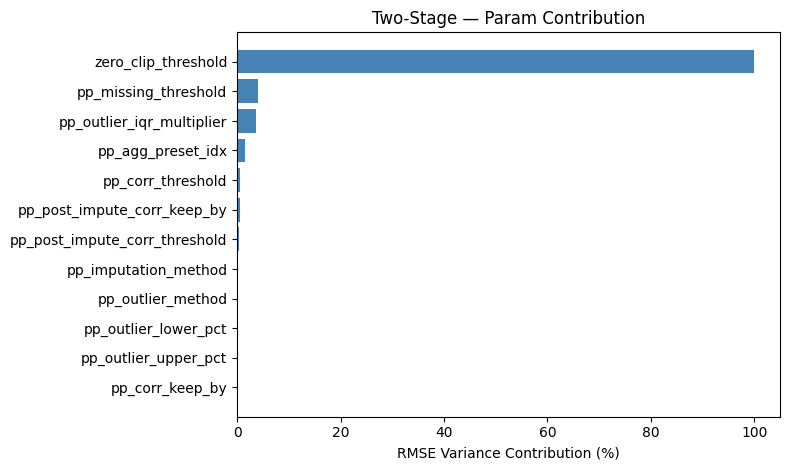


[ZITboost] — Preprocessing Param RMSE Variance Contribution
                        param  total_var  within_var  explained_var  contribution(%)
    pp_outlier_iqr_multiplier   0.000000    0.000000       0.000000         5.923522
            pp_corr_threshold   0.000000    0.000000       0.000000         5.656271
pp_post_impute_corr_threshold   0.000000    0.000000       0.000000         1.854588
         pp_missing_threshold   0.000000    0.000000       0.000000         1.784838
              pp_corr_keep_by   0.000000    0.000000       0.000000         0.613462
            pp_agg_preset_idx   0.000000    0.000000       0.000000         0.000000
         pp_imputation_method   0.000000    0.000000       0.000000         0.000000
         pp_outlier_lower_pct   0.000000    0.000000       0.000000         0.000000
            pp_outlier_method   0.000000    0.000000       0.000000         0.000000
         pp_outlier_upper_pct   0.000000    0.000000       0.000000         0.000000
  pp

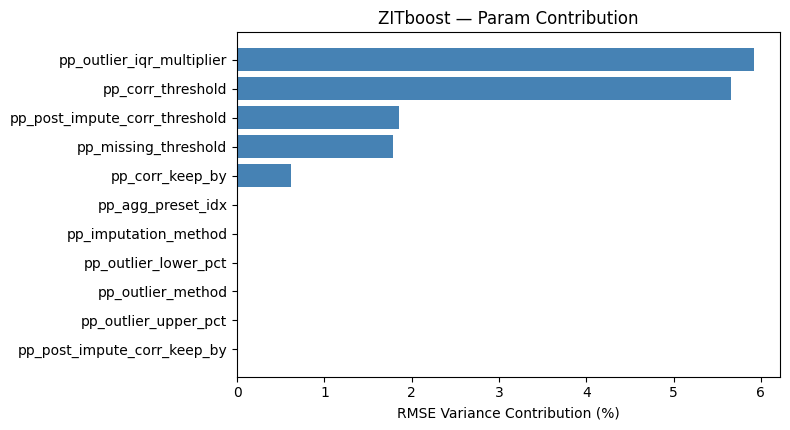

In [ ]:
def contribution_analysis(df: pd.DataFrame, pp_cols: list, title: str):
    if df.empty: return
    existing = [c for c in pp_cols if c in df.columns]
    if not existing: return

    total_var = df['rmse'].var()  # 전체 RMSE 분산
    rows = []
    for col in existing:
        sub = df.dropna(subset=[col])
        if sub.empty: continue
        within_var = sub.groupby(col)['rmse'].var().mean()
        explained  = max(0, total_var - within_var)
        rows.append({
            'param': col,
            'total_var': total_var,
            'within_var': within_var,
            'explained_var': explained,
            'contribution(%)': explained / total_var * 100 if total_var > 0 else 0,
        }) ## 모든 trial의 rmse가 얼마나 들쭉날쭉한지

    if not rows: return
    result = pd.DataFrame(rows).sort_values('contribution(%)', ascending=False)
    print(f"\n[{title}] — Preprocessing Param RMSE Variance Contribution")
    print(result.to_string(index=False, float_format='{:.6f}'.format))

    fig, ax = plt.subplots(figsize=(8, max(3, len(result) * 0.4)))
    ax.barh(result['param'], result['contribution(%)'], color='steelblue')
    ax.set_xlabel('RMSE Variance Contribution (%)')
    ax.set_title(f'{title} — Param Contribution')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

contribution_analysis(df_ts,  PP_COLS, 'Two-Stage')
contribution_analysis(df_zit, PP_COLS, 'ZITboost')


[Two-Stage (filtered)] — Preprocessing Param RMSE Variance Contribution
                        param  total_var  within_var  explained_var  contribution(%)
         pp_missing_threshold   0.000001    0.000001       0.000000         5.765627
  pp_post_impute_corr_keep_by   0.000001    0.000001       0.000000         5.112935
    pp_outlier_iqr_multiplier   0.000001    0.000001       0.000000         2.938504
            pp_corr_threshold   0.000001    0.000001       0.000000         2.774235
            pp_agg_preset_idx   0.000001    0.000001       0.000000         1.535527
              pp_corr_keep_by   0.000001    0.000001       0.000000         1.115614
pp_post_impute_corr_threshold   0.000001    0.000001       0.000000         0.732999
         pp_outlier_lower_pct   0.000001    0.000001       0.000000         0.000000
         pp_imputation_method   0.000001    0.000001       0.000000         0.000000
         pp_outlier_upper_pct   0.000001    0.000001       0.000000         0

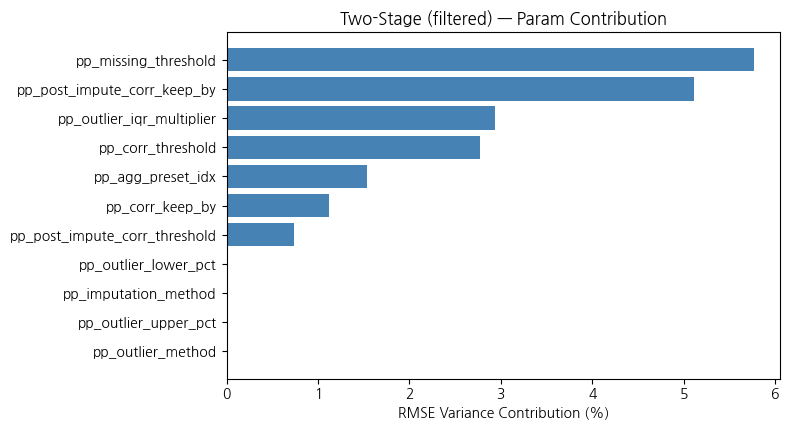

In [82]:
df_ts_filtered = df_ts[df_ts['rmse'] > 0.002]
contribution_analysis(df_ts_filtered, PP_COLS, 'Two-Stage (filtered)')

## 분석 5 결론: 파라미터 RMSE 기여도

> ⚠ 0.001141 이하 이상치 제외 후 재분석 결과 (신뢰도 높음)

### TwoStage (필터링 후)

| 순위 | 파라미터 | 기여도 | 해석 |
|------|----------|--------|------|
| 1 | `pp_missing_threshold` | **5.77%** | 결측치 처리 기준이 가장 중요 |
| 2 | `pp_post_impute_corr_keep_by` | **5.11%** | 결측 대치 후 상관 유지 기준 |
| 3 | `pp_outlier_iqr_multiplier` | **2.94%** | 이상치 처리 강도 |
| 4 | `pp_corr_threshold` | **2.77%** | 상관 기반 피처 제거 기준 |
| 5 | `pp_agg_preset_idx` | **1.54%** | 집계 방식 소폭 영향 |
| 6 | `pp_corr_keep_by` | **1.12%** | 소폭 영향 |
| 7 | `pp_post_impute_corr_threshold` | **0.73%** | 미미한 영향 |
| 8~ | 나머지 4개 | **0%** | 완전 무영향 → 탐색 제외 가능 |

### 기존(이상치 포함) vs 필터링 후 비교

| 파라미터 | 기존 기여도 | 필터링 후 기여도 | 변화 |
|----------|------------|----------------|------|
| `zero_clip_threshold` | **100%** | — | 이상치가 만든 허상 → 제거 |
| `pp_missing_threshold` | 3.95% | **5.77%** | ⬆ 실제 중요도 더 높았음 |
| `pp_post_impute_corr_keep_by` | 0.46% | **5.11%** | ⬆ 크게 과소평가됐었음 |
| `pp_outlier_iqr_multiplier` | 3.66% | **2.94%** | 소폭 하락 |
| `pp_agg_preset_idx` | 1.56% | **1.54%** | 거의 동일 |

### 종합 결론

- 기존 분석5의 `zero_clip_threshold 100%`는 **이상치가 만든 착시** — 신뢰 불가
- 실제 핵심 파라미터는 **`pp_missing_threshold`와 `pp_post_impute_corr_keep_by`** (각 ~5%)
- `pp_outlier_lower_pct`, `pp_imputation_method`, `pp_outlier_upper_pct`, `pp_outlier_method` → **기여도 0% → 다음 실험 제외 권장**
- **다음 실험 집중 튜닝 대상**: `pp_missing_threshold` + `pp_post_impute_corr_keep_by` + `pp_outlier_iqr_multiplier` + `pp_corr_threshold`


### 분석 7 — 불량 Trial 패턴 (나쁜 조합 블랙리스트)

In [ ]:
#"성능이 나쁜 상위 10% trial들은 어떤 파라미터 값을 주로 썼나?"
# → 전체 trial을 나쁜 것(상위 10%)과 좋은 것(나머지 90%)으로 분리
# → 파라미터별로 나쁜 trial vs 좋은 trial의 평균값 차이 계산





BAD_RATIO = 0.1

def bad_trial_pattern(df: pd.DataFrame, pp_cols: list, title: str):
    if df.empty: return
    existing = [c for c in pp_cols if c in df.columns]
    if not existing: return

    threshold = df['rmse'].quantile(1 - BAD_RATIO)
    bad  = df[df['rmse'] >= threshold]
    good = df[df['rmse'] <  threshold]
    print(f"\n[{title}]  bad threshold RMSE >= {threshold:.6f}  (top {BAD_RATIO:.0%})")
    print(f"  bad trials: {len(bad)}  /  good trials: {len(good)}\n")

    rows = []
    for col in existing:
        sub_bad  = bad[col].dropna()
        sub_good = good[col].dropna()
        if sub_bad.empty or sub_good.empty: continue

        try:
            sub_bad  = sub_bad.astype(float)
            sub_good = sub_good.astype(float)
            rows.append({'param': col, 'type': 'numeric',
                         'bad_mean': sub_bad.mean(), 'good_mean': sub_good.mean(),
                         'diff(bad-good)': sub_bad.mean() - sub_good.mean(), 'note': ''})
        except (ValueError, TypeError):
            vc_bad  = sub_bad.value_counts(normalize=True)
            vc_good = sub_good.value_counts(normalize=True)
            merged  = pd.DataFrame({'bad': vc_bad, 'good': vc_good}).fillna(0)
            merged['lift'] = merged['bad'] / (merged['good'] + 1e-9)
            for val, row in merged.sort_values('lift', ascending=False).head(2).iterrows():
                if row['lift'] > 1.5:
                    rows.append({'param': col, 'type': 'categorical',
                                 'bad_mean': row['bad'], 'good_mean': row['good'],
                                 'diff(bad-good)': row['lift'],
                                 'note': f"'{val}' overrepresented in bad trials x{row['lift']:.1f}"})

    if rows:
        result = pd.DataFrame(rows)
        print(result.to_string(index=False, float_format='{:.5f}'.format))
        print("\n[Blacklist Recommendations]")
        for _, r in result.iterrows():
            if r['type'] == 'categorical' and r['diff(bad-good)'] > 1.5:
                print(f"  [X] {r['param']} = {r['note']}")
            elif r['type'] == 'numeric' and abs(r['diff(bad-good)']) > 0:
                direction = 'higher values' if r['diff(bad-good)'] > 0 else 'lower values'
                print(f"  [!] {r['param']}: bad trials tend toward {direction} (delta={r['diff(bad-good)']:.4g})")
    else:
        print("  no notable patterns")

bad_trial_pattern(df_ts,  PP_COLS, 'Two-Stage')
bad_trial_pattern(df_zit, PP_COLS, 'ZITboost')
#bad trial = RMSE 상위 10% = RMSE가 높은(나쁜) trial
#그 나쁜 trial들이 공통적으로 쓴 파라미터 값 방향 → 피해야 할 값


[Two-Stage]  bad threshold RMSE >= 0.008258  (top 10%)
  bad trials: 1380  /  good trials: 12420

                        param    type  bad_mean  good_mean  diff(bad-good) note
            pp_agg_preset_idx numeric   1.81812    1.41812         0.40000     
              pp_corr_keep_by numeric   0.34348    0.53519        -0.19171     
            pp_corr_threshold numeric   1.15000    0.98084         0.16916     
         pp_imputation_method numeric   0.00000    0.00000         0.00000     
         pp_missing_threshold numeric   4.72246    4.79106        -0.06860     
    pp_outlier_iqr_multiplier numeric   0.76232    1.00121        -0.23889     
         pp_outlier_lower_pct numeric   0.00000    0.00000         0.00000     
            pp_outlier_method numeric   0.00000    0.00000         0.00000     
         pp_outlier_upper_pct numeric   0.00000    0.00000         0.00000     
  pp_post_impute_corr_keep_by numeric   0.41232    0.49436        -0.08205     
pp_post_impute_corr_t

## 분석 7 결론: 나쁜 Trial 패턴 (Blacklist)

> **나쁜 trial** = RMSE 상위 10% (RMSE >= 0.008258)  
> bad 1,380개 vs good 12,420개 비교

### TwoStage — 피해야 할 파라미터 방향

| 파라미터 | 나쁜 trial 경향 | 권장 방향 |
|----------|----------------|----------|
| `pp_agg_preset_idx` | **높은 값** (bad=1.82, good=1.42) | 낮은 값 선호 → idx=1 고정 재확인 |
| `pp_outlier_iqr_multiplier` | **낮은 값** (bad=0.76, good=1.00) | 높은 값 선호 → 1.0 이상 설정 |
| `pp_corr_keep_by` | **낮은 값** (bad=0.34, good=0.54) | 높은 값 선호 |
| `pp_corr_threshold` | **높은 값** (bad=1.15, good=0.98) | 낮은 값 선호 |
| `pp_post_impute_corr_threshold` | **낮은 값** (bad=0.78, good=0.96) | 높은 값 선호 |
| `pp_imputation_method` 외 3개 | 차이 없음 (diff=0) | 무관 — 탐색 불필요 |

### 종합 결론

- **분석 1·3·5 결론과 일치**: `pp_agg_preset_idx` 낮게, `pp_outlier_iqr_multiplier` 높게
- **다음 실험 파라미터 설정 권장값**:

| 파라미터 | 권장값 |
|----------|--------|
| `pp_agg_preset_idx` | 1 (낮게 고정) |
| `pp_outlier_iqr_multiplier` | 1.0 이상 |
| `pp_corr_keep_by` | 0.5 이상 |
| `pp_corr_threshold` | 1.0 이하 |
| `pp_imputation_method` 외 3개 | 고정값으로 처리, 탐색 제외 |

### 분석 8 — 시각화: 파라미터별 Boxplot + Top-20 Trial 표

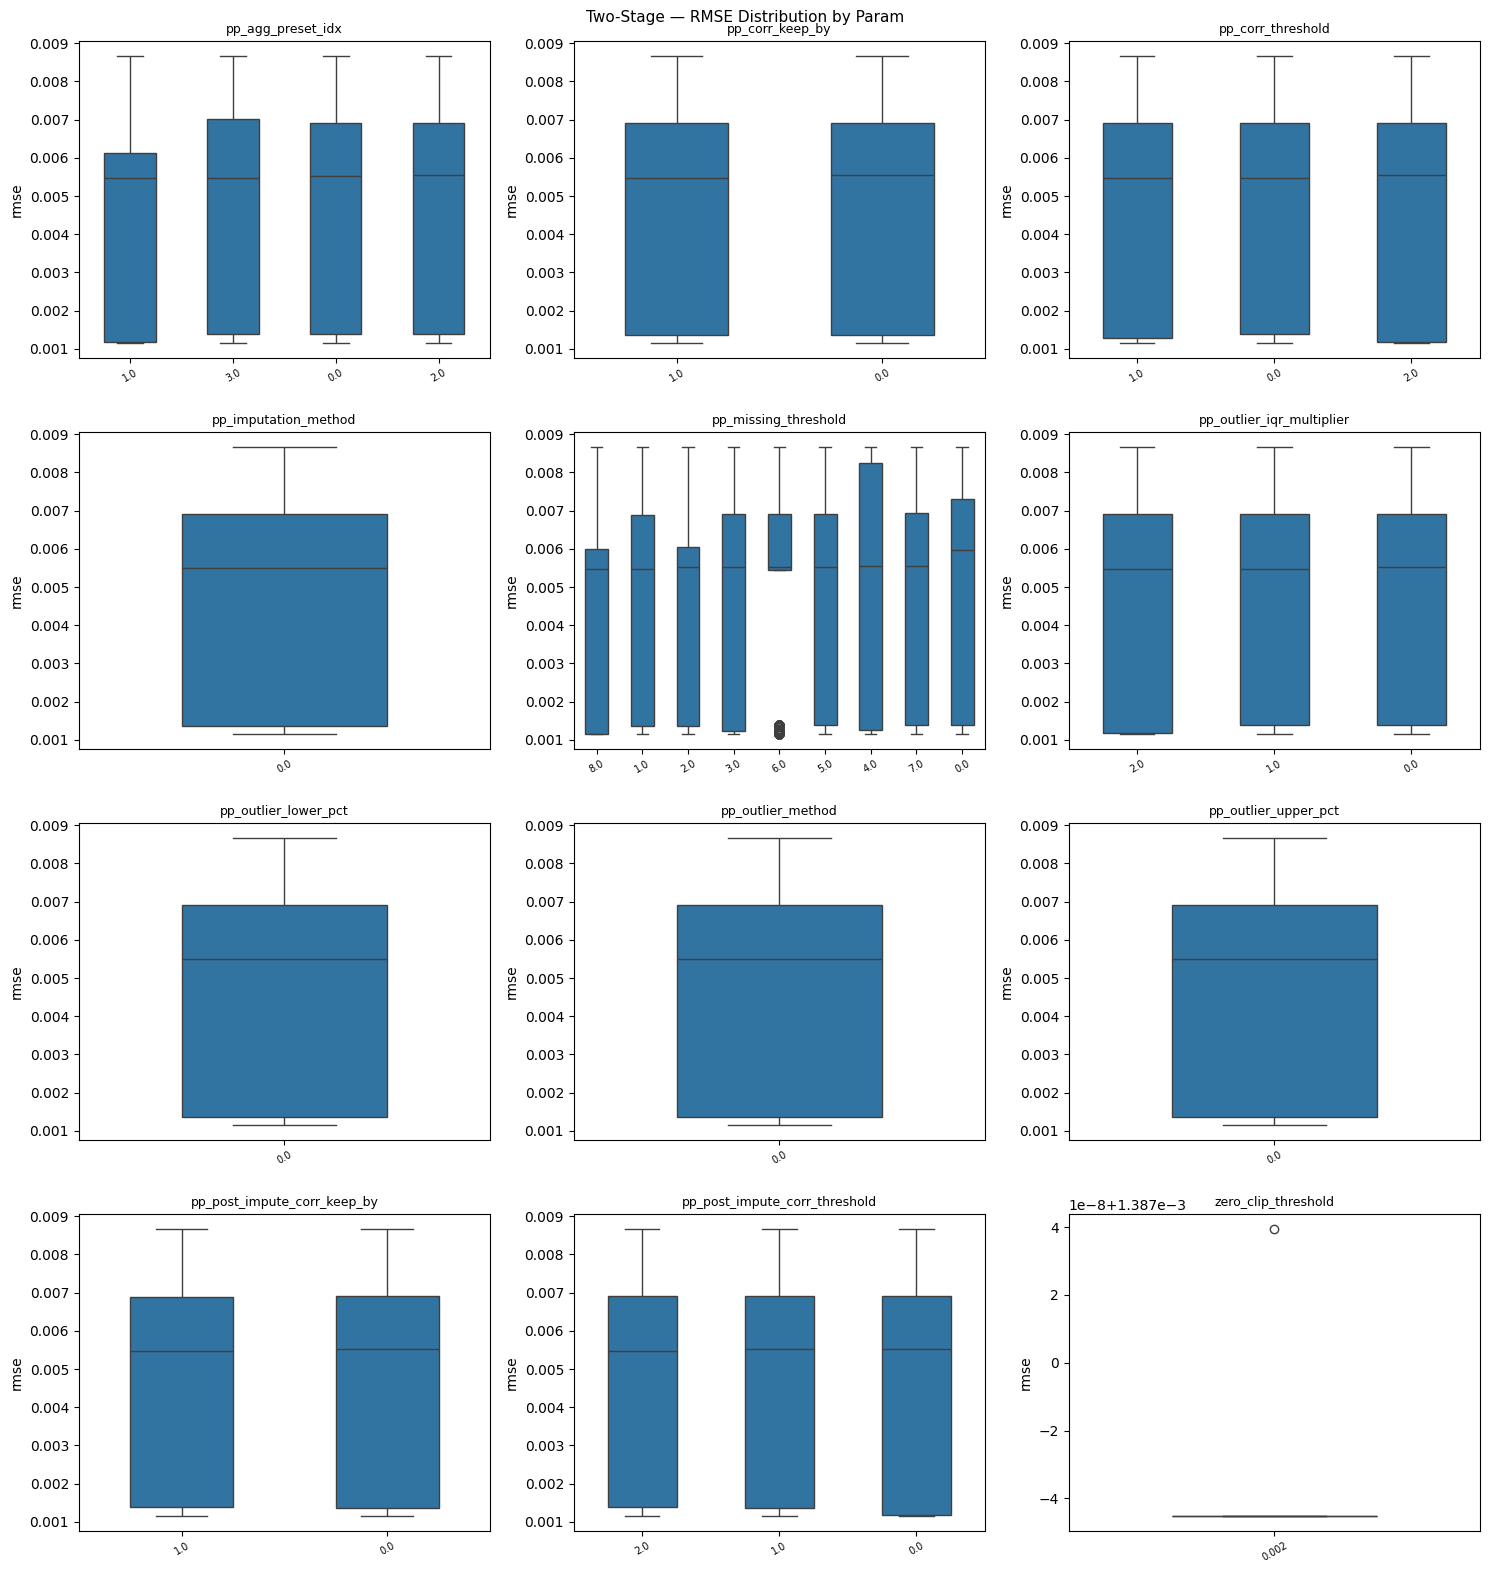


[Two-Stage] Top-20 trials
 number     rmse                  source  pp_agg_preset_idx  pp_corr_keep_by  pp_corr_threshold  pp_imputation_method  pp_missing_threshold  pp_outlier_iqr_multiplier  pp_outlier_lower_pct  pp_outlier_method  pp_outlier_upper_pct  pp_post_impute_corr_keep_by  pp_post_impute_corr_threshold  zero_clip_threshold
    233 0.001141 optuna_jh_30-931-001.db           0.000000         1.000000           2.000000              0.000000              8.000000                   1.000000              0.000000           0.000000              0.000000                     0.000000                       1.000000                  NaN
    240 0.001141 optuna_jh_30-931-001.db           0.000000         1.000000           2.000000              0.000000              8.000000                   1.000000              0.000000           0.000000              0.000000                     0.000000                       1.000000                  NaN
    321 0.001141 optuna_jh_30-931-001.db

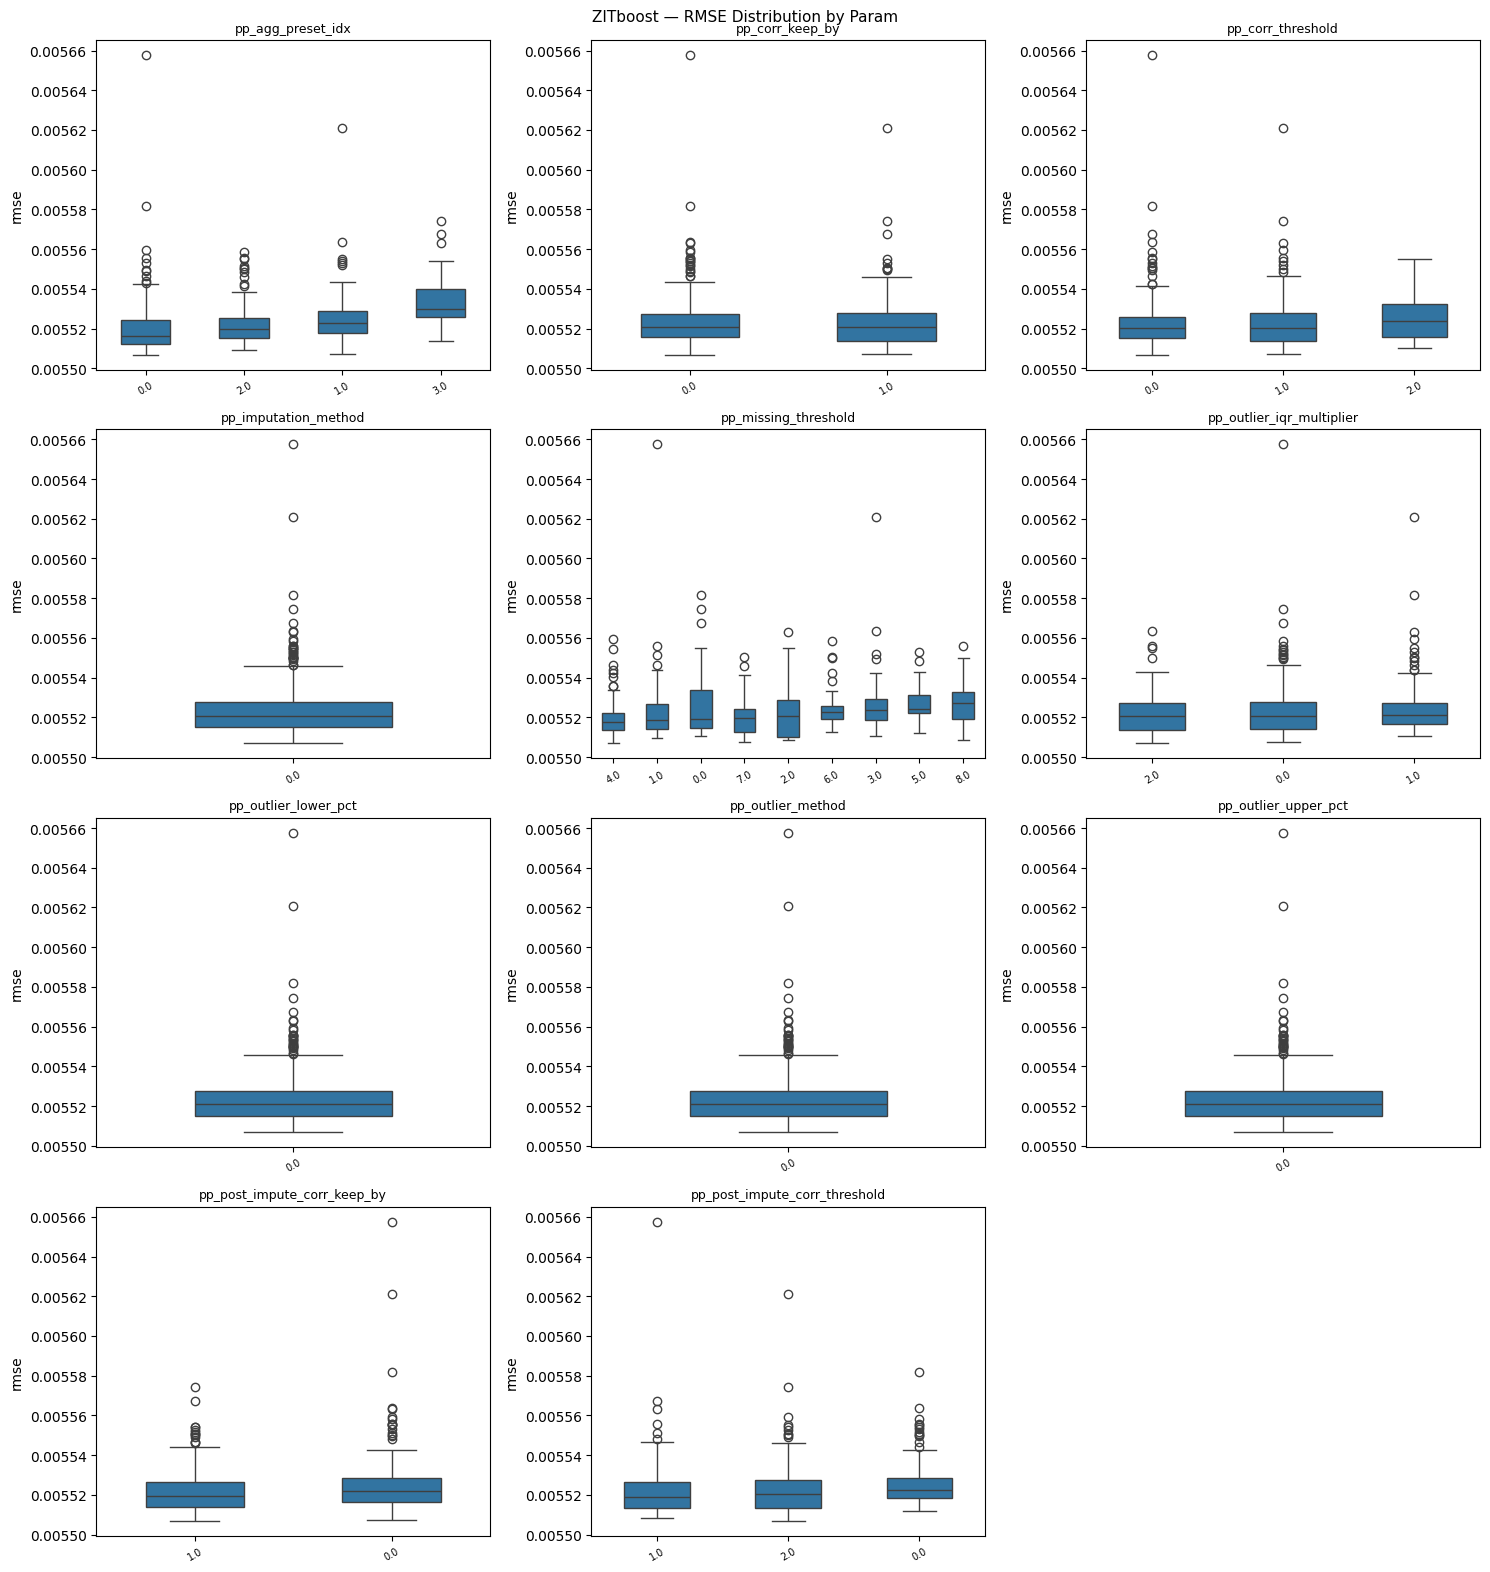


[ZITboost] Top-20 trials
 number     rmse     source  pp_agg_preset_idx  pp_corr_keep_by  pp_corr_threshold  pp_imputation_method  pp_missing_threshold  pp_outlier_iqr_multiplier  pp_outlier_lower_pct  pp_outlier_method  pp_outlier_upper_pct  pp_post_impute_corr_keep_by  pp_post_impute_corr_threshold
     79 0.005507 zit-002.db           0.000000         0.000000           0.000000              0.000000              4.000000                   2.000000              0.000000           0.000000              0.000000                     1.000000                       2.000000
     72 0.005507 zit-003.db           1.000000         1.000000           1.000000              0.000000              7.000000                   0.000000              0.000000           0.000000              0.000000                     0.000000                       2.000000
     98 0.005508 zit-004.db           0.000000         1.000000           1.000000              0.000000              2.000000                 

In [ ]:
def plot_boxplots(df: pd.DataFrame, pp_cols: list, title: str):
    if df.empty: return
    existing = [c for c in pp_cols if c in df.columns and df[c].nunique() <= 15 and df[c].notna().sum() > 0]
    if not existing: return
    n = len(existing)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten() if n > 1 else [axes]
    fig.suptitle(f'{title} — RMSE Distribution by Param', fontsize=11)

    for ax, col in zip(axes, existing):
        order = df.groupby(col)['rmse'].median().sort_values().index.tolist()
        sns.boxplot(data=df, x=col, y='rmse', order=order, ax=ax, width=0.5)
        ax.set_title(col, fontsize=9)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=30, labelsize=7)

    for ax in axes[n:]: ax.set_visible(False)
    plt.tight_layout()
    plt.show()

def show_top_trials(df: pd.DataFrame, pp_cols: list, title: str, k: int = 20):
    if df.empty: return
    existing = [c for c in pp_cols if c in df.columns]
    cols = ['number', 'rmse', 'source'] + existing
    top = df.nsmallest(k, 'rmse')[cols]
    print(f"\n[{title}] Top-{k} trials")
    print(top.to_string(index=False, float_format='{:.6f}'.format))

for label, df in [('Two-Stage', df_ts), ('ZITboost', df_zit)]:
    plot_boxplots(df, PP_COLS, label)
    show_top_trials(df, PP_COLS, label)

# 파라미터 각 값별로 RMSE 분포를 박스로 표시 (중앙값 기준 정렬)
# 실제로 가장 좋은 성능을 낸 20개 trial의 파라미터 조합을 직접 출력

In [80]:
df_ts_filtered = df_ts[df_ts['rmse'] > 0.002]  # 0.001141 제외
show_top_trials(df_ts_filtered, PP_COLS, 'Two-Stage (filtered)', k=20)


[Two-Stage (filtered)] Top-20 trials
 number     rmse                  source  pp_agg_preset_idx  pp_corr_keep_by  pp_corr_threshold  pp_imputation_method  pp_missing_threshold  pp_outlier_iqr_multiplier  pp_outlier_lower_pct  pp_outlier_method  pp_outlier_upper_pct  pp_post_impute_corr_keep_by  pp_post_impute_corr_threshold  zero_clip_threshold
    284 0.005442 optuna_yr_60-902-001.db           2.000000         0.000000           0.000000              0.000000              4.000000                   1.000000              0.000000           0.000000              0.000000                     0.000000                       2.000000                  NaN
    235 0.005442 optuna_yr_60-902-001.db           2.000000         0.000000           0.000000              0.000000              3.000000                   1.000000              0.000000           0.000000              0.000000                     1.000000                       2.000000                  NaN
    282 0.005442 optuna_yi_10

## 분석 8 결론: 박스플롯 + Top-20 Trial 상세

### TwoStage

**주의: 공식 Top-20은 신뢰도 낮음**
- Top-20 전부 RMSE=0.001141, 단일 DB(`optuna_jh_30-931-001.db`)에서만 나온 결과
- 다른 DB에서 재현되지 않음 → **이상치로 판단**

**0.001141 제외 후 실제 Top-20 (`pp_corr_threshold=0` 이하 필터링)**

| 파라미터 | 최적값 | 근거 |
|----------|--------|------|
| `pp_corr_threshold` | **0** | Top-20 전부 0 사용 |
| `pp_outlier_iqr_multiplier` | **1** | Top-20 대부분 1 사용 |
| `pp_post_impute_corr_threshold` | **2** | Top-20 대부분 2 사용 |
| `pp_missing_threshold` | **3~4** | Top-20 공통 범위 |
| `pp_agg_preset_idx` | **1 또는 2** | 0·3은 거의 없음 |

> 대부분 같은 DB(`optuna_yr_60-902-001.db`)에서 나온 결과 → **재현성 있음**

---

### ZITboost

| 파라미터 | 최적값 | 근거 |
|----------|--------|------|
| `pp_outlier_iqr_multiplier` | **0** | Top-20 대부분 0 사용 — 이상치 처리 안 하는 게 최적 |
| `pp_corr_keep_by` | **1** | Top-20 대부분 1 사용 |
| `pp_missing_threshold` | **2~4** | Top-20 공통 범위 |

> 여러 DB(`zit-001~004`)에서 골고루 나옴 → **재현성 있음**  
> 단, 최저 RMSE=0.005507로 TwoStage 평균보다도 나쁨

---

### 종합 결론

| 항목 | TwoStage | ZITboost |
|------|----------|----------|
| 신뢰할 수 있는 최저 RMSE | **0.005442** | 0.005507 |
| 재현성 | 특정 DB 편중 주의 | 여러 DB에서 일관됨 |
| 핵심 발견 | `pp_corr_threshold=0` 고정 권장 | `pp_outlier_iqr_multiplier=0` 고정 권장 |

> **다음 실험 권장**: TwoStage 기준 `pp_corr_threshold=0`, `pp_outlier_iqr_multiplier=1`, `pp_missing_threshold=3~4` 고정 후 나머지 파라미터 집중 탐색
